In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



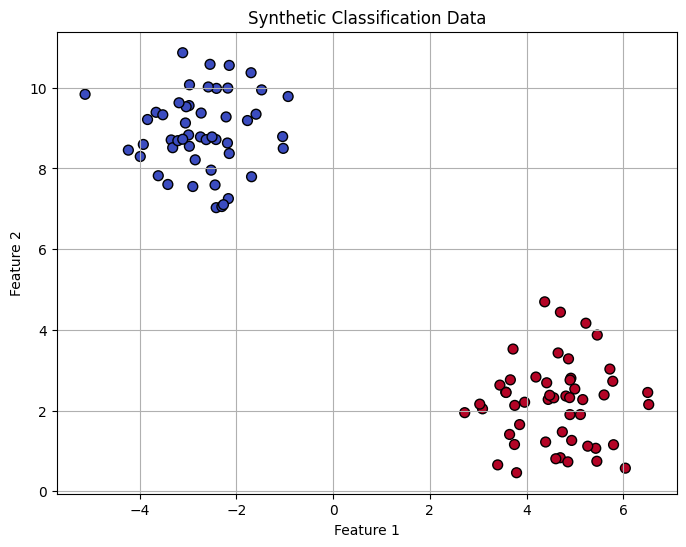

In [2]:

X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.0)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Classification Data')
plt.grid(True)
plt.show()

In [3]:
def plot_svm_decision_boundary(X, y, classifier, title):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')


    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)


    plt.scatter(classifier.support_vectors_[:, 0], classifier.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='green', label='Support Vectors')


    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()


    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    P = classifier.decision_function(xy).reshape(xx.shape)

    ax.contour(xx, yy, P, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

C = 0.01: Accuracy = 1.0000


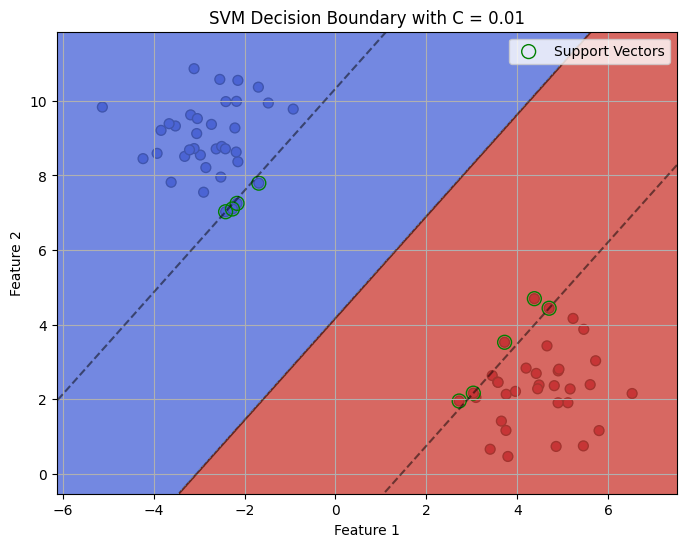

C = 0.1: Accuracy = 1.0000


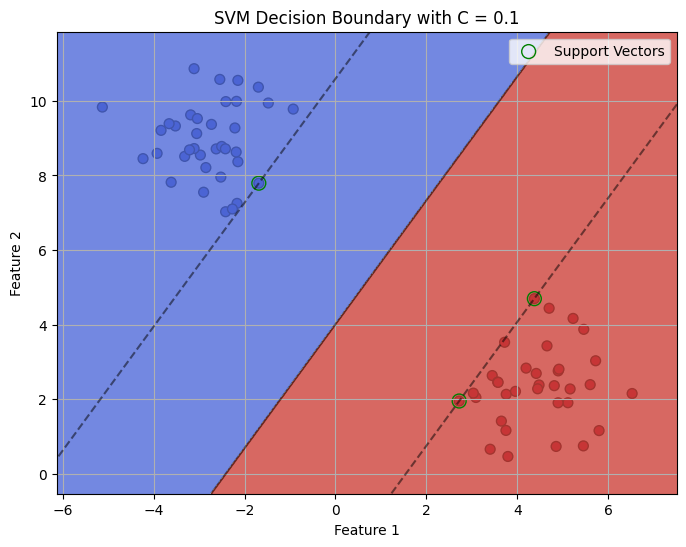

C = 1: Accuracy = 1.0000


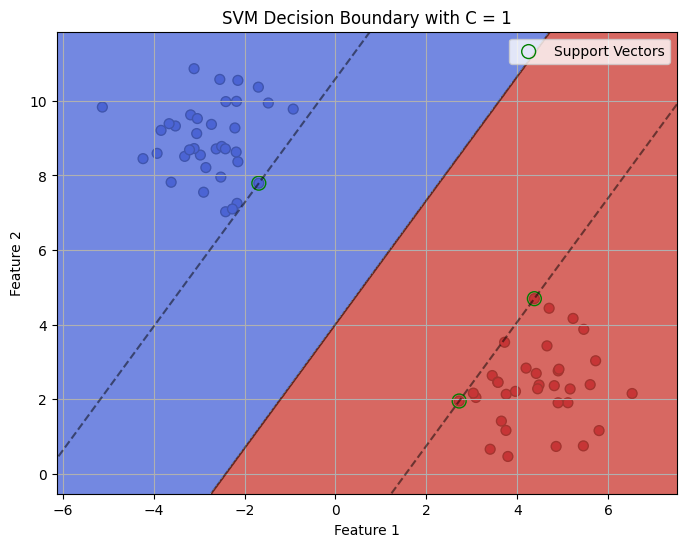

C = 10: Accuracy = 1.0000


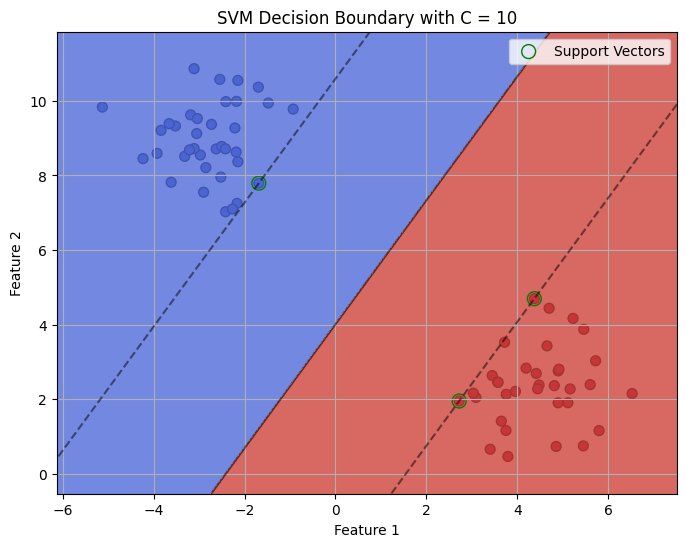

C = 100: Accuracy = 1.0000


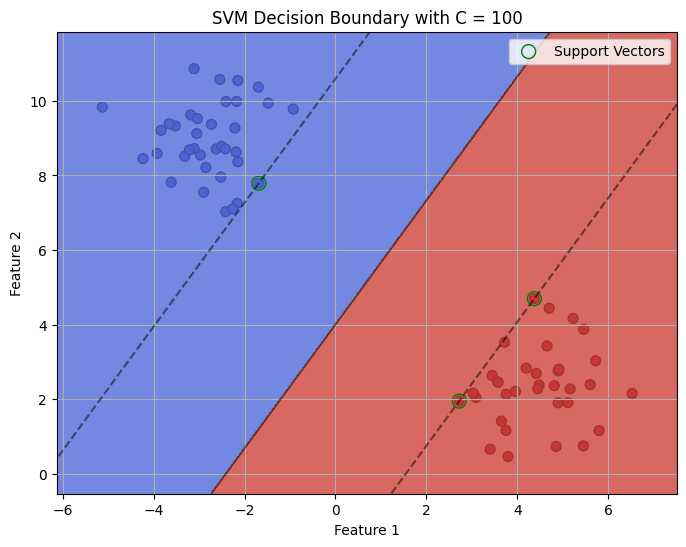

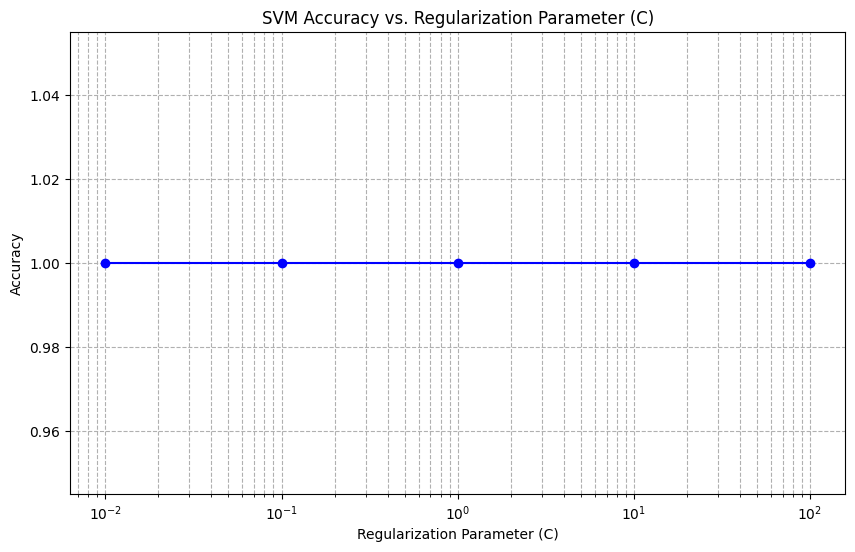

In [4]:

c_values = [0.01, 0.1, 1, 10, 100]

accuracies = []

for C in c_values:

    svc = svm.SVC(kernel='linear', C=C, random_state=42)


    svc.fit(X_train, y_train)

    y_pred = svc.predict(X_test)


    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    print(f"C = {C}: Accuracy = {accuracy:.4f}")


    plot_svm_decision_boundary(X_train, y_train, svc, f'SVM Decision Boundary with C = {C}')


plt.figure(figsize=(10, 6))
plt.plot(c_values, accuracies, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy vs. Regularization Parameter (C)')
plt.grid(True, which="both", ls="--")
plt.show()